In [1]:
# Pregnancies — patient kitni baar pregnant hui hai (count)
# Glucose — plasma glucose concentration (oral glucose tolerance test se, mg/dl mein)
# BloodPressure — diastolic blood pressure (mm Hg)
# SkinThickness — triceps skin fold thickness (mm) — body fat ka indicator
# Insulin — 2-hour serum insulin level (mu U/ml)
# BMI — Body Mass Index (weight in kg / height in m²) — obesity ka measure
# DiabetesPedigreeFunction — ek score jo family history/genetics ke basis pe diabetes risk batata hai (jitna zyada, family mein diabetes history zyada strong)
# Age — patient ki age (years)
# Outcome — target/label: 1 = diabetic, 0 = not diabetic

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
df = pd.read_csv('/content/diabetes.csv')

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df.shape

(768, 9)

In [14]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [15]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [16]:
X = df.drop(columns=['Outcome'])  # independent variables
Y = df['Outcome']                 # dependent variable (0 or 1)

In [17]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [18]:
Y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [20]:
print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (614, 8)
Testing samples : (154, 8)


In [21]:
model = RandomForestClassifier(random_state=42)

In [22]:
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [23]:
Y_pred = model.predict(X_test)

In [24]:
accuracy  = accuracy_score(Y_test, Y_pred)    # overall correct predictions
precision = precision_score(Y_test, Y_pred)   # of predicted diabetics, how many correct
recall    = recall_score(Y_test, Y_pred)      # of actual diabetics, how many caught
f1        = f1_score(Y_test, Y_pred)          # balance of precision and recall

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.7208
Precision : 0.6071
Recall    : 0.6182
F1 Score  : 0.6126


In [25]:
cm = confusion_matrix(Y_test, Y_pred)

In [26]:
cm

array([[77, 22],
       [21, 34]])

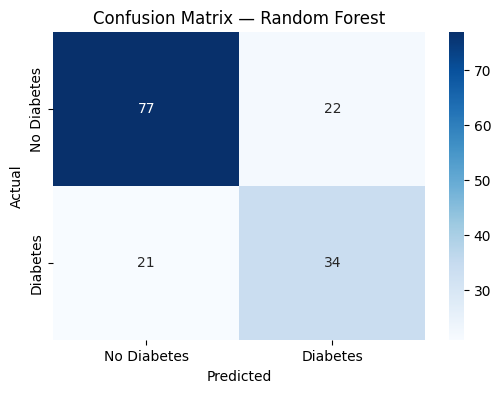

In [27]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()